In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import datetime
import scipy.stats
#import plotly.offline as pyo
#import plotly.graph_objects as go
#import plotly.express as px
#from plotly.subplots import make_subplots
#import plotly.colors as cl
import matplotlib.dates as mdates
import matplotlib
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import seaborn as sns
import netCDF4 as nc
import xarray as xr
#import cartopy.crs as ccrs
#from cartopy import feature as cfa
import os

In [1]:
%run ../../../2025-12-20_AgeModel-NewXrayPatch/age_model/20260215_read_data.py

In [4]:
path = os.getcwd()
path

'C:\\Users\\mkara\\Desktop\\Academics\\Coral\\2026-02-03_Age-Model\\Python\\claude'

In [6]:
pd.read_csv(path+'\\age_estimates_corrected_20260216.csv')

,index,Name,Mass,Amp 44,Area 44,sample,age1,age_end,age2,path_name,...,d13c,d18o,age_lin_raw,age_lin,age_xray,age2_is_integer,age_bayes,age_bayes_lower,age_bayes_upper,age_uncertainty
0,339,12 SPL-A4 Path I 1A,0.198,8213.0,99.041,I 1A,NaN,NaN,43.9,I,...,-1.131600,25.462473,43.233333,43.233333,1972.050000,False,1971.917245,1971.787520,1972.033901,0.246381
1,340,Path I 2A,0.234,9744.0,117.440,I 2A,NaN,NaN,NaN,I,...,-0.959254,25.506770,NaN,43.283333,1972.100000,False,1972.048567,1971.940516,1972.145243,0.204728
2,341,Path I 3A,0.242,11042.0,133.385,I 3A,-1.0,NaN,44.0,I,...,-1.147898,25.437887,43.333333,43.333333,1972.150000,True,1972.176047,1972.094434,1972.257415,0.162981
3,342,Path I 4A,0.198,10023.0,120.887,I 4A,NaN,NaN,NaN,I,...,-1.546483,25.767988,NaN,44.083333,1972.900000,False,1972.330007,1972.228894,1972.436951,0.208057
4,343,Path I 5A,0.228,9899.0,119.531,I 5A,NaN,45.0,NaN,I,...,-1.283402,25.880993,44.833333,44.833333,1973.650000,False,1972.484395,1972.371095,1972.603011,0.231916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,569,12 SPL A4 Path H 109A,0.246,12144.0,154.275,H 109A,1.0,NaN,78.0,H,...,-2.460117,25.200643,77.333333,77.333333,2006.150000,True,2006.168967,2006.095132,2006.246108,0.150976
231,570,12 SPL A4 Path H 110A,0.240,12574.0,152.695,H 110A,NaN,NaN,NaN,H,...,-2.570089,25.228860,NaN,77.666667,2006.483333,False,2006.469222,2006.307260,2006.667122,0.359862
232,571,12 SPL A4 Path H 111A,0.282,14484.0,183.010,H 111A,NaN,NaN,NaN,H,...,-2.434808,25.392241,NaN,78.000000,2006.816667,False,2006.784169,2006.570586,2006.948250,0.377664
233,572,12 SPL A4 Path H 112A,0.234,12889.0,160.079,H 112A,1.0,NaN,79.0,H,...,-2.779113,25.554687,78.333333,78.333333,2007.150000,True,2007.085919,2007.014852,2007.156637,0.141785


In [12]:
MODEL = pd.read_csv('age_estimates_corrected_20260216.csv')
MODEL

,index,Name,Mass,Amp 44,Area 44,sample,age1,age_end,age2,path_name,...,d13c,d18o,age_lin_raw,age_lin,age_xray,age2_is_integer,age_bayes,age_bayes_lower,age_bayes_upper,age_uncertainty
0,339,12 SPL-A4 Path I 1A,0.198,8213.0,99.041,I 1A,NaN,NaN,43.9,I,...,-1.131600,25.462473,43.233333,43.233333,1972.050000,False,1971.917245,1971.787520,1972.033901,0.246381
1,340,Path I 2A,0.234,9744.0,117.440,I 2A,NaN,NaN,NaN,I,...,-0.959254,25.506770,NaN,43.283333,1972.100000,False,1972.048567,1971.940516,1972.145243,0.204728
2,341,Path I 3A,0.242,11042.0,133.385,I 3A,-1.0,NaN,44.0,I,...,-1.147898,25.437887,43.333333,43.333333,1972.150000,True,1972.176047,1972.094434,1972.257415,0.162981
3,342,Path I 4A,0.198,10023.0,120.887,I 4A,NaN,NaN,NaN,I,...,-1.546483,25.767988,NaN,44.083333,1972.900000,False,1972.330007,1972.228894,1972.436951,0.208057
4,343,Path I 5A,0.228,9899.0,119.531,I 5A,NaN,45.0,NaN,I,...,-1.283402,25.880993,44.833333,44.833333,1973.650000,False,1972.484395,1972.371095,1972.603011,0.231916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,569,12 SPL A4 Path H 109A,0.246,12144.0,154.275,H 109A,1.0,NaN,78.0,H,...,-2.460117,25.200643,77.333333,77.333333,2006.150000,True,2006.168967,2006.095132,2006.246108,0.150976
231,570,12 SPL A4 Path H 110A,0.240,12574.0,152.695,H 110A,NaN,NaN,NaN,H,...,-2.570089,25.228860,NaN,77.666667,2006.483333,False,2006.469222,2006.307260,2006.667122,0.359862
232,571,12 SPL A4 Path H 111A,0.282,14484.0,183.010,H 111A,NaN,NaN,NaN,H,...,-2.434808,25.392241,NaN,78.000000,2006.816667,False,2006.784169,2006.570586,2006.948250,0.377664
233,572,12 SPL A4 Path H 112A,0.234,12889.0,160.079,H 112A,1.0,NaN,79.0,H,...,-2.779113,25.554687,78.333333,78.333333,2007.150000,True,2007.085919,2007.014852,2007.156637,0.141785


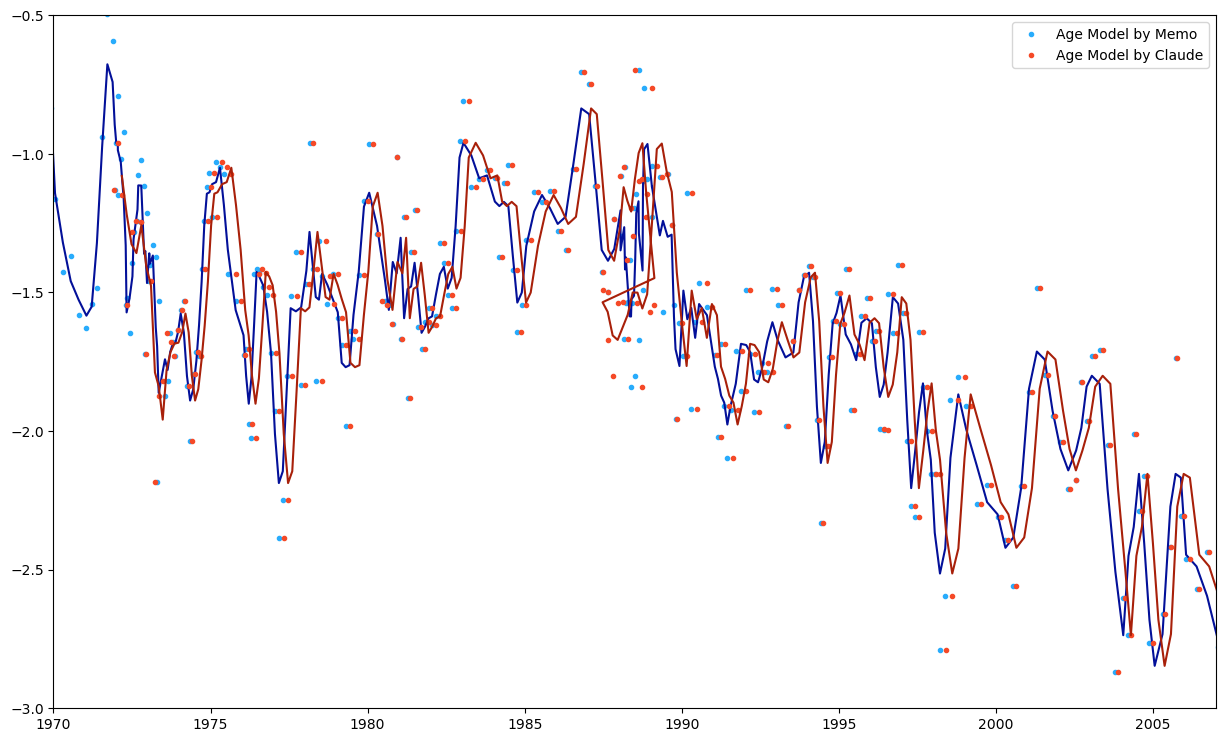

In [13]:
fig, ax = plt.subplots(1, figsize=(15,9))

ax.plot(df_sorted['age_absolute'], df_sorted['d13c'], '.', color='#28ACFC' ,label='Age Model by Memo')
ax.plot(df_sorted['age_absolute'], df_sorted['d13c_ma'], color='#031099')
#ax.plot(df_sorted['age_absolute'], df_sorted['d13c_ma2'])

ax.plot(MODEL['age_bayes'], MODEL['d13c'], '.', color='#F54927', label='Age Model by Claude')
ax.plot(MODEL['age_bayes'], MODEL['d13c'].rolling(window_size).mean(), '-', color='#A8200A')


ax.set_xlim(1970, 2007)
ax.set_ylim(-3, -0.5)
ax.legend()

fig.savefig('Memo_Bayesian_timeseries.pdf')


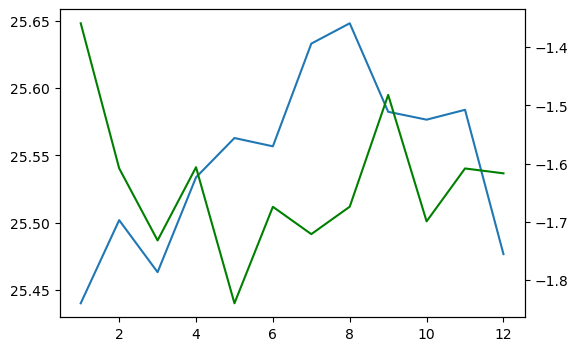

In [14]:
MODEL['age_bayes_month'] = decimal_year_to_datetime(MODEL['age_bayes']).dt.month
MODEL_monthly = MODEL[['age_bayes_month','d13c', 'd18o']].groupby('age_bayes_month').mean()
MODEL['d18o']


fig, ax = plt.subplots(1, figsize=(6,4))


ax.plot(MODEL_monthly['d18o'])

ax2 = ax.twinx()
ax2.plot(MODEL_monthly['d13c'], color='green')

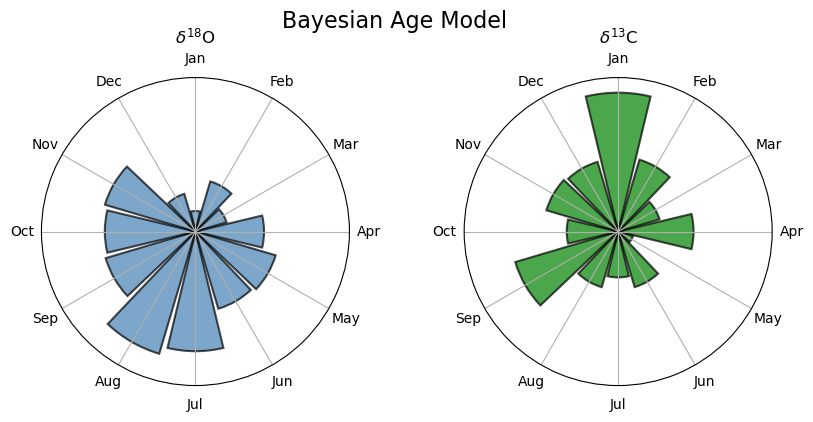

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': 'polar'})

ax = axes[0]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
width = 2*np.pi/12 * 0.9  # 90% of bin width (small gap)

rmin, rmax = 25.4, 25.7
vals = MODEL_monthly['d18o'].values

# Make bars start at rmin, and only show the variation within [rmin, rmax]
heights = np.clip(vals, rmin, rmax) - rmin

ax.bar(theta, heights, width=width, bottom=rmin,
       color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_rlim(rmin, rmax)

ax.set_rticks([])
ax.set_xticks(theta)
ax.set_xticklabels(months)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

ax.set_title(r'$\delta^{18}$O')


ax = axes[1]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
width = 2*np.pi/12 * 0.9  # 90% of bin width (small gap)

rmin, rmax = -1.9, -1.3
vals = MODEL_monthly['d13c'].values

# Make bars start at rmin, and only show the variation within [rmin, rmax]
heights = np.clip(vals, rmin, rmax) - rmin

ax.bar(theta, heights, width=width, bottom=rmin,
       color='green', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_rlim(rmin, rmax)

ax.set_rticks([])
ax.set_xticks(theta)
ax.set_xticklabels(months)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

ax.set_title(r'$\delta^{13}$C')

plt.suptitle('Bayesian Age Model', y= 1.05 , fontsize=16)


fig.savefig('claude_age_model_d13c_d18o_monthly_means.pdf',bbox_inches='tight' )

In [16]:
MODEL_monthly

,d13c,d18o
age_bayes_month,,
1,-1.358880,25.439975
2,-1.608167,25.501795
3,-1.732130,25.463102
4,-1.606275,25.533652
5,-1.840131,25.562883
6,-1.674282,25.556707
7,-1.721290,25.633095
8,-1.674108,25.648222
9,-1.481993,25.582394


In [9]:
%run ../../../2025-12-20_AgeModel-NewXrayPatch/age_model/20260215_read_data.py

In [19]:
df_sorted['age_dt_month'] = df_sorted['age_dt'].dt.month

In [20]:
monthly = df_sorted[['age_dt_month','d13c', 'd18o']].groupby('age_dt_month').mean()
monthly['d18o']

age_dt_month
1     25.574468
2     25.604897
3     25.609736
4     25.622007
5     25.700390
6     25.779274
7     25.717594
8     25.673387
9     25.694691
10    25.672807
11    25.619314
12    25.571071
Name: d18o, dtype: float64

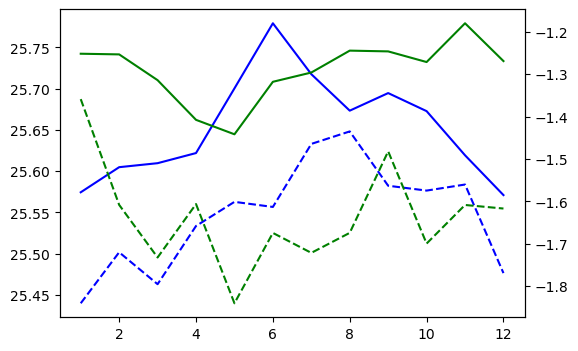

In [24]:
fig, ax = plt.subplots(1, figsize=(6,4))


ax.plot(monthly['d18o'], color='blue')
ax.plot(MODEL_monthly['d18o'], '--', color='blue')
ax.set_



ax2 = ax.twinx()
ax2.plot(monthly['d13c'], color='green')
ax2.plot(MODEL_monthly['d13c'],  '--',color='green')


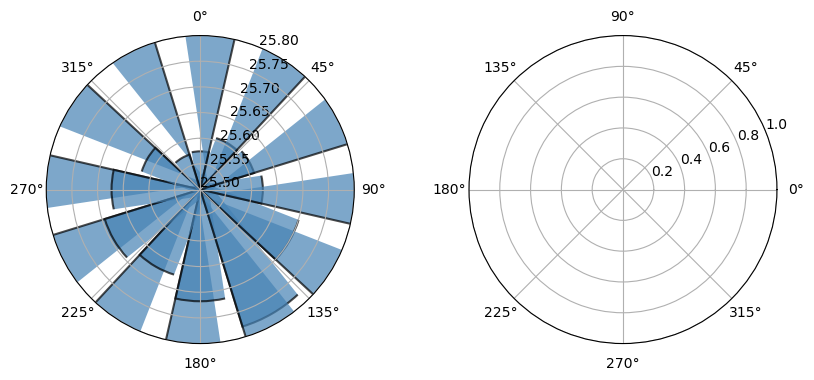

In [63]:
fig, axes = plt.subplots(1,2, figsize=(10,4), subplot_kw={'projection': 'polar'})

ax = axes[0]

theta = np.linspace(0, 2*np.pi, 12, endpoint=False)    
width = 2 * np.pi / 14  # Width of each bar
ax.bar(theta, monthly['d18o'].values, width=width, color='steelblue',
               alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_rmin(25.5)  # Set the minimum radius
ax.set_rmax(25.8)  # Set the maximum radius
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

ax = axes[1]

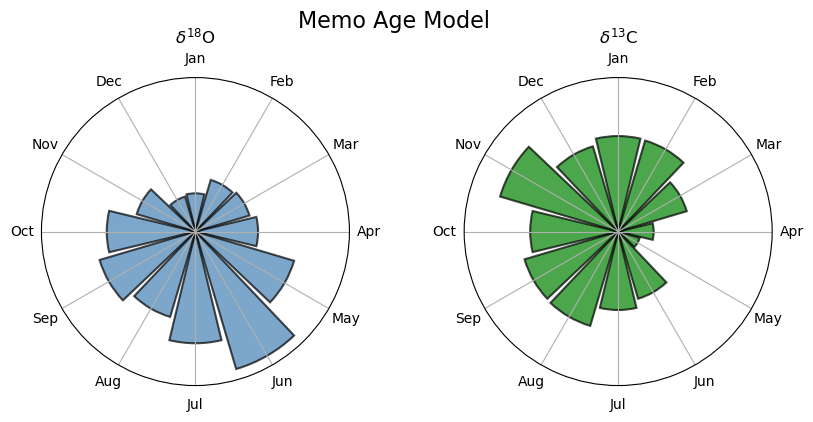

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': 'polar'})

ax = axes[0]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
width = 2*np.pi/12 * 0.9  # 90% of bin width (small gap)

rmin, rmax = 25.5, 25.8
vals = monthly['d18o'].values

# Make bars start at rmin, and only show the variation within [rmin, rmax]
heights = np.clip(vals, rmin, rmax) - rmin

ax.bar(theta, heights, width=width, bottom=rmin,
       color='steelblue', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_rlim(rmin, rmax)

ax.set_rticks([])
ax.set_xticks(theta)
ax.set_xticklabels(months)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

ax.set_title(r'$\delta^{18}$O')


ax = axes[1]

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
width = 2*np.pi/12 * 0.9  # 90% of bin width (small gap)

rmin, rmax = -1.5, -1.1
vals = monthly['d13c'].values

# Make bars start at rmin, and only show the variation within [rmin, rmax]
heights = np.clip(vals, rmin, rmax) - rmin

ax.bar(theta, heights, width=width, bottom=rmin,
       color='green', alpha=0.7, edgecolor='black', linewidth=1.5)

ax.set_rlim(rmin, rmax)

ax.set_rticks([])
ax.set_xticks(theta)
ax.set_xticklabels(months)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

ax.set_title(r'$\delta^{13}$C')

plt.suptitle('Memo Age Model', y= 1.05 , fontsize=16)

fig.savefig('memo_age_model_d13c_d18o_monthly_means.pdf',bbox_inches='tight' )